# IPL Player Detection — Feature Extraction
**Group 42 | IITB PML Sem 1**

This notebook extracts all visual features for each 100×75 px grid cell across every image and saves the result to `pipeline/features/ps1/cell_features.csv`.

**Output:** one row per cell, 63,488 rows (992 images × 64 cells), 274 columns

| Feature group | Columns | Description |
|---|---|---|
| HSV/RGB histograms | `f000`–`f191` (192) | 64-bin histograms for Hue, Saturation, Value channels |
| Texture (LBP + GLCM) | `tex_00`–`tex_25` (26) | 10 LBP + 16 GLCM (contrast/homogeneity/energy/correlation × 4 angles) |
| Edge | `f_edge_density`, `f_canny_count`, `f_sobel_mean`, `f_sobel_std`, `f_laplacian_var`, `f_contour_count` (6) | Canny, Sobel, Laplacian statistics |
| HOG orientation | `f_hog_000`–`f_hog_035` (36) | 4 cells-per-block × 9-orientation HOG descriptor |
| HOG 9-bin | `hog_bin_0`–`hog_bin_8` (9) | Single 9-bin HOG for the whole cell |

**Images are downloaded from HuggingFace** on first run (cached locally).
**Annotations CSV** (`Dataset_Annotations.csv`) must be present in `pipeline/labels/`.

## 1. Imports & Configuration

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from skimage.color import rgb2gray

# ── Config ────────────────────────────────────────────────────────────────────
# Images already exist locally in pipeline/images/train/ and pipeline/images/test/
# No HuggingFace download needed.
ANNOTATIONS_CSV  = Path('.') / 'labels' / 'Dataset_Annotations.csv'
OUTPUT_CSV       = Path('.') / 'features' / 'ps1' / 'cell_features.csv'
IMG_TRAIN        = Path('.') / 'images' / 'train'
IMG_TEST         = Path('.') / 'images' / 'test'

# Images are 800×600, grid is 8×8
IMG_W, IMG_H = 800, 600
GRID_ROWS, GRID_COLS = 8, 8
CELL_W = IMG_W // GRID_COLS   # 100
CELL_H = IMG_H // GRID_ROWS   # 75

# Images to exclude (confirmed bad quality — see pipeline notebook §2b)
EXCLUDED_IMAGES = {
    'img_1006.jpg','img_1007.jpg','img_1008.jpg','img_1009.jpg',
    'img_1010.jpg','img_1011.jpg','img_1012.jpg','img_1013.jpg',
    'img_89.jpg','img_144.jpg','img_201.jpg','img_267.jpg',
    'img_271.jpg','img_276.jpg','img_281.jpg','img_402.jpg',
    'img_423.jpg','img_454.jpg','img_517.jpg','img_661.jpg','img_753.jpg',
}

print(f'Output CSV   : {OUTPUT_CSV}')
print(f'Train images : {IMG_TRAIN}  ({len(list(IMG_TRAIN.glob("*.jpg")))} files)')
print(f'Test images  : {IMG_TEST}   ({len(list(IMG_TEST.glob("*.jpg")))} files)')
print(f'Cell size    : {CELL_W}×{CELL_H} px')
print(f'Excluded     : {len(EXCLUDED_IMAGES)} images')


## 2. Load Annotations & Download Images

In [ ]:
# ── Load annotations ──────────────────────────────────────────────────────────
annotations = pd.read_csv(ANNOTATIONS_CSV)

# Remove excluded images
annotations = annotations[~annotations['Image File Name'].isin(EXCLUDED_IMAGES)].reset_index(drop=True)

print(f'Annotations  : {len(annotations)} images after exclusions')
print(f'Train / Test : {(annotations["Train Or Test"]=="Train").sum()} / {(annotations["Train Or Test"]=="Test").sum()}')

def find_image(img_name, split):
    """Return image path from local pipeline/images/train or test folder."""
    p = (IMG_TRAIN if split.lower() == 'train' else IMG_TEST) / img_name
    if p.exists():
        return p
    # fallback: search both dirs
    for d in [IMG_TRAIN, IMG_TEST]:
        q = d / img_name
        if q.exists():
            return q
    return None

# Quick sanity check on first image
first = annotations.iloc[0]
p = find_image(first['Image File Name'], first['Train Or Test'])
print(f'\nSample image found: {p}')


## 3. Feature Extraction Functions

One function per feature group. All operate on a single cropped cell (100×75 px PIL/numpy patch).

In [ ]:
# ── HSV/RGB histograms — 192 features (f000–f191) ─────────────────────────────
def extract_hsv_features(patch_pil):
    """
    64-bin histograms for each of the 3 HSV channels.
    Returns 192 integer counts.
    """
    hsv = np.array(patch_pil.convert('HSV'))
    h_hist, _ = np.histogram(hsv[:,:,0], bins=64, range=(0, 256))
    s_hist, _ = np.histogram(hsv[:,:,1], bins=64, range=(0, 256))
    v_hist, _ = np.histogram(hsv[:,:,2], bins=64, range=(0, 256))
    return np.concatenate([h_hist, s_hist, v_hist]).astype(int)  # 192 values

In [ ]:
# ── Texture: LBP + GLCM — 26 features (tex_00–tex_25) ────────────────────────
def extract_texture_features(patch_rgb):
    """
    10 LBP uniform histogram values + 16 GLCM properties.
    Input: (75, 100, 3) uint8 numpy array.
    Returns 26 float values.
    """
    gray = (rgb2gray(patch_rgb) * 255).astype(np.uint8)

    # LBP — 10 values
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
    lbp_hist = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-6)  # normalised

    # GLCM — 4 properties × 4 angles = 16 values
    gray_q = (gray / 8).astype(np.uint8)  # quantise to 32 levels
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray_q, distances=[1], angles=angles,
                        levels=32, symmetric=True, normed=True)
    glcm_feats = []
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        glcm_feats.extend(graycoprops(glcm, prop).ravel())  # 4 values per prop

    return np.concatenate([lbp_hist, glcm_feats])  # 26 values

In [ ]:
# ── Edge features — 6 values ─────────────────────────────────────────────────
def compute_edge_maps(image_bgr):
    """Compute full-image edge maps once per image (reused for all 64 cells)."""
    gray    = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    canny   = cv2.Canny(blurred, threshold1=50, threshold2=150)
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
    return {'canny': canny, 'sobel_mag': sobel_mag, 'laplacian': laplacian}

def extract_edge_features(edge_maps, x1, y1, x2, y2):
    """
    Returns 6 values:
      f_edge_density, f_canny_count, f_sobel_mean, f_sobel_std,
      f_laplacian_var, f_contour_count
    """
    canny_cell   = edge_maps['canny'][y1:y2, x1:x2]
    sobel_cell   = edge_maps['sobel_mag'][y1:y2, x1:x2]
    lap_cell     = edge_maps['laplacian'][y1:y2, x1:x2]
    area         = canny_cell.shape[0] * canny_cell.shape[1]

    canny_count  = int(np.count_nonzero(canny_cell))
    edge_density = canny_count / area if area > 0 else 0.0
    sobel_mean   = float(np.mean(sobel_cell))
    sobel_std    = float(np.std(sobel_cell))
    lap_var      = float(np.var(lap_cell))

    # Contour count from the Canny cell
    cnts, _      = cv2.findContours(canny_cell, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_count = len(cnts)

    return [edge_density, canny_count, sobel_mean, sobel_std, lap_var, contour_count]

In [ ]:
# ── HOG features — 36 orientation + 9 bin = 45 values ────────────────────────
def extract_hog_features(patch_rgb):
    """
    Returns 45 values:
      f_hog_000–f_hog_035  : 4-cell HOG descriptor (36 values)
      hog_bin_0–hog_bin_8  : single 9-bin HOG for whole cell (9 values)
    Input: (75, 100, 3) uint8 numpy array.
    """
    gray = rgb2gray(patch_rgb)   # (75, 100) float64

    # 36-value descriptor: 2×2 blocks of cells, 9 orientations
    # pixels_per_cell=(37,50) → 2 cells across each axis → 4 cells × 9 = 36
    hog_36 = hog(
        gray,
        orientations=9,
        pixels_per_cell=(37, 50),
        cells_per_block=(1, 1),
        feature_vector=True,
        channel_axis=None
    )

    # 9-bin: treat entire cell as one block
    hog_9 = hog(
        gray,
        orientations=9,
        pixels_per_cell=(75, 100),
        cells_per_block=(1, 1),
        feature_vector=True,
        channel_axis=None
    )

    return hog_36, hog_9   # shapes (36,) and (9,)

## 4. Main Extraction Loop

Processes one image at a time. Edge maps are computed once per image and reused for all 64 cells.

In [ ]:
CELL_COLS = [f'c{i:02d}' for i in range(1, 65)]
rows      = []
missing   = []

for _, ann_row in tqdm(annotations.iterrows(), total=len(annotations), desc='Extracting features'):
    img_name  = ann_row['Image File Name']
    split     = ann_row['Train Or Test']
    img_path  = find_image(img_name, split)

    if img_path is None:
        missing.append(img_name)
        continue

    # Load image in both formats needed
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_W, IMG_H))
    img_rgb = np.array(img_pil, dtype=np.uint8)                  # (600,800,3)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)            # for OpenCV

    # Compute edge maps once per image
    edge_maps = compute_edge_maps(img_bgr)

    # Extract image_number (integer from filename, e.g. img_42.jpg → 42)
    try:
        image_number = int(''.join(filter(str.isdigit, img_name.split('.')[0])))
    except Exception:
        image_number = -1

    cell_idx = 0
    for cell_row in range(GRID_ROWS):
        for cell_col in range(GRID_COLS):
            cell_idx += 1
            x1 = cell_col * CELL_W
            y1 = cell_row * CELL_H
            x2 = x1 + CELL_W
            y2 = y1 + CELL_H

            label  = int(ann_row[f'c{cell_idx:02d}'])
            patch_pil = img_pil.crop((x1, y1, x2, y2))
            patch_rgb = img_rgb[y1:y2, x1:x2]

            # Extract all features
            hsv_feats  = extract_hsv_features(patch_pil)           # 192
            tex_feats  = extract_texture_features(patch_rgb)       # 26
            edge_feats = extract_edge_features(edge_maps, x1, y1, x2, y2)  # 6
            hog_36, hog_9 = extract_hog_features(patch_rgb)        # 36 + 9

            record = {
                'Image File Name': img_name,
                'Train Or Test'  : split,
                'cell_row'       : cell_row,
                'cell_col'       : cell_col,
                'label'          : label,
            }

            # HSV/RGB: f000–f191
            for i, v in enumerate(hsv_feats):
                record[f'f{i:03d}'] = int(v)

            # Texture: tex_00–tex_25
            for i, v in enumerate(tex_feats):
                record[f'tex_{i:02d}'] = float(v)

            # Edge: 6 named features
            names = ['f_edge_density','f_canny_count','f_sobel_mean',
                     'f_sobel_std','f_laplacian_var','f_contour_count']
            for n, v in zip(names, edge_feats):
                record[n] = v

            # HOG orientation: f_hog_000–f_hog_035
            for i, v in enumerate(hog_36):
                record[f'f_hog_{i:03d}'] = float(v)

            # HOG 9-bin: hog_bin_0–hog_bin_8
            for i, v in enumerate(hog_9):
                record[f'hog_bin_{i}'] = float(v)

            # Surrogate image number
            record['image_number'] = image_number

            rows.append(record)

print(f'\nExtracted  : {len(rows):,} rows from {len(annotations)-len(missing)} images')
if missing:
    print(f'Missing    : {len(missing)} images — {missing[:5]}')

## 5. Validate & Save

In [ ]:
df_out = pd.DataFrame(rows)

# ── Validate column count and order ──────────────────────────────────────────
expected_cols = (
    ['Image File Name', 'Train Or Test', 'cell_row', 'cell_col', 'label'] +
    [f'f{i:03d}' for i in range(192)] +
    [f'tex_{i:02d}' for i in range(26)] +
    ['f_edge_density','f_canny_count','f_sobel_mean','f_sobel_std','f_laplacian_var','f_contour_count'] +
    [f'f_hog_{i:03d}' for i in range(36)] +
    [f'hog_bin_{i}' for i in range(9)] +
    ['image_number']
)

assert list(df_out.columns) == expected_cols, \
    f'Column mismatch!\nGot:      {list(df_out.columns)}\nExpected: {expected_cols}'

print(f'Shape       : {df_out.shape}  (expected ~63,488 × 274)')
print(f'Unique imgs : {df_out["Image File Name"].nunique()}  (expected 992)')
print(f'Columns     : {len(df_out.columns)}  (expected 274)')
print(f'Missing vals: {df_out.isnull().sum().sum()}')
print(f'\nColumn groups:')
print(f'  HSV/RGB (f000-f191)  : {sum(1 for c in df_out.columns if c.startswith("f") and c[1:].isdigit())}')
print(f'  Texture (tex_*)      : {sum(1 for c in df_out.columns if c.startswith("tex_"))}')
print(f'  Edge (f_edge_*/f_canny_*/...) : {sum(1 for c in df_out.columns if any(c.startswith(p) for p in ["f_edge","f_canny","f_sobel","f_laplacian","f_contour"]))}')
print(f'  HOG orientation (f_hog_*) : {sum(1 for c in df_out.columns if c.startswith("f_hog_"))}')
print(f'  HOG 9-bin (hog_bin_*) : {sum(1 for c in df_out.columns if c.startswith("hog_bin_"))}')

# ── Save ──────────────────────────────────────────────────────────────────────
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(OUTPUT_CSV, index=False)
print(f'\n✓ Saved → {OUTPUT_CSV}  ({OUTPUT_CSV.stat().st_size/1024**2:.1f} MB)')

## 6. Feature Visualizations

Three charts — one per feature family — drawn from the saved `cell_features.csv`.
These confirm the extracted values are sensible and show the discriminative power of each group.

> Run these after the extraction loop (cell 12) has completed and the CSV has been saved.


Loaded: 63,488 rows × 274 cols  |  992 images


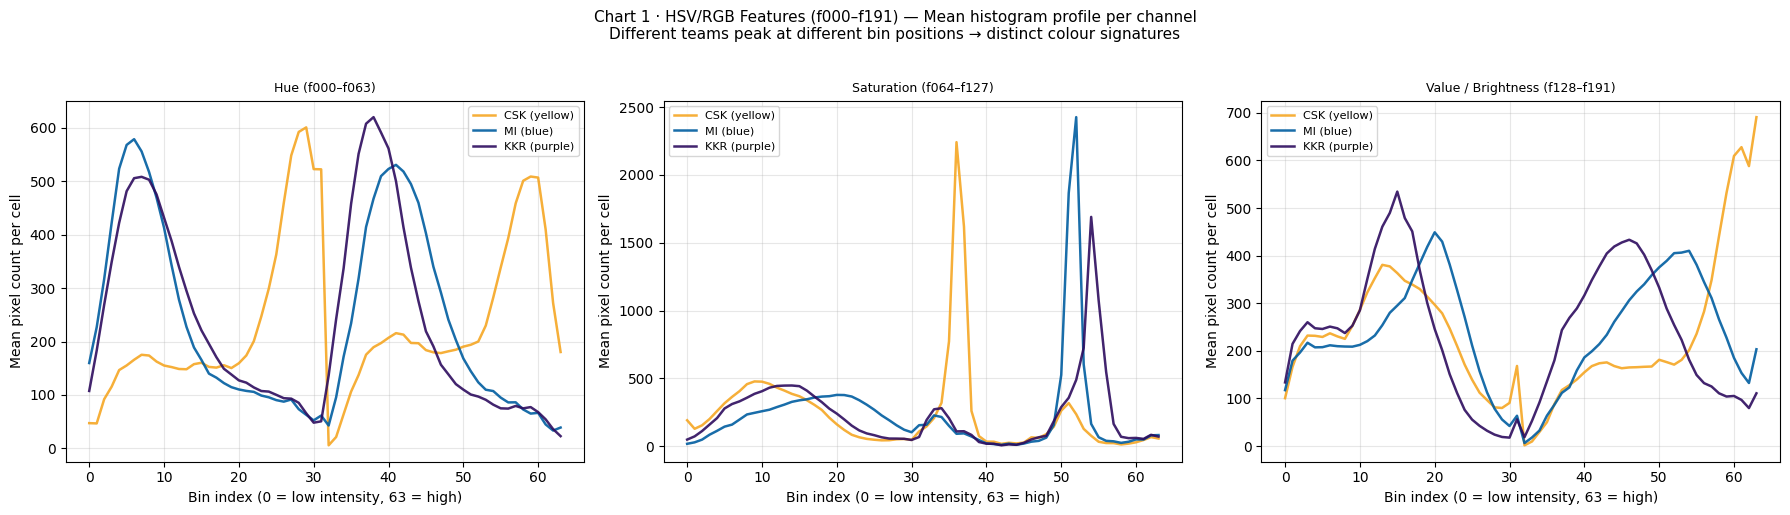

HSV feature range: 0 – 7500  (raw pixel counts)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the saved CSV (works even if extraction was run in a previous session)
_df = pd.read_csv('../pipeline/features/ps1/cell_features.csv')
_teams = {0:'Background',1:'CSK',2:'DC',3:'GT',4:'KKR',5:'LSG',6:'MI',7:'PBKS',8:'RR',9:'RCB',10:'SRH'}
_pal   = ['#aaaaaa','#f5a623','#1a78cf','#374975','#2d0c5e','#00b4d8','#005da0','#cc1133','#e75480','#c8102e','#f56a1a']
_player = _df[_df['label'] > 0]

print(f"Loaded: {_df.shape[0]:,} rows × {_df.shape[1]} cols  |  {_df['Image File Name'].nunique()} images")

# ──────────────────────────────────────────────────────────────────────────────
# Chart 1 · HSV/RGB — Mean histogram profile for CSK vs MI vs KKR
# Shows that teams have genuinely distinct colour signatures across the 192 bins
# ──────────────────────────────────────────────────────────────────────────────
hue_cols = [f'f{i:03d}' for i in range(64)]
sat_cols = [f'f{i:03d}' for i in range(64, 128)]
val_cols = [f'f{i:03d}' for i in range(128, 192)]

# Pick 3 visually distinctive teams
focus_teams = {1: 'CSK (yellow)', 6: 'MI (blue)', 4: 'KKR (purple)'}
focus_colors = {1: '#f5a623', 6: '#005da0', 4: '#2d0c5e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channel_data = [('Hue (f000–f063)', hue_cols), ('Saturation (f064–f127)', sat_cols), ('Value / Brightness (f128–f191)', val_cols)]

for ax, (title, cols) in zip(axes, channel_data):
    for label_id, team_name in focus_teams.items():
        team_df = _player[_player['label'] == label_id]
        profile = team_df[cols].mean().values
        ax.plot(range(64), profile, label=team_name, color=focus_colors[label_id], lw=1.8, alpha=0.9)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Bin index (0 = low intensity, 63 = high)'); ax.set_ylabel('Mean pixel count per cell')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Chart 1 · HSV/RGB Features (f000–f191) — Mean histogram profile per channel\n'
             'Different teams peak at different bin positions → distinct colour signatures',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()
print(f"HSV feature range: 0 – {_df[hue_cols + sat_cols + val_cols].values.max():.0f}  (raw pixel counts)")


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Chart 2 · Texture (LBP + GLCM) — Distribution comparison: Player vs Background
# Shows why tex_00–tex_25 are discriminative — jerseys have distinct textures
# ──────────────────────────────────────────────────────────────────────────────
tex_cols = [f'tex_{i:02d}' for i in range(26)]

# Split player vs background
bg     = _df[_df['label'] == 0]
player = _df[_df['label'] > 0]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Select 8 most representative texture features for display
sel_feats = [
    # LBP (tex_00–tex_09) — uniform pattern bins
    'tex_00', 'tex_03', 'tex_06', 'tex_09',
    # GLCM (tex_10–tex_25) — contrast/homogeneity/energy/correlation @ 4 angles
    'tex_10', 'tex_14', 'tex_18', 'tex_22',
]

labels = {
    'tex_00': 'LBP bin 0',   'tex_03': 'LBP bin 3',
    'tex_06': 'LBP bin 6',   'tex_09': 'LBP bin 9',
    'tex_10': 'GLCM Contrast 0°', 'tex_14': 'GLCM Homog 0°',
    'tex_18': 'GLCM Energy 0°',   'tex_22': 'GLCM Corr 0°',
}

for ax, feat in zip(axes.flat, sel_feats):
    # Clip outliers for readability
    vmax = float(np.percentile(player[feat], 99))
    ax.hist(bg[feat].clip(0, vmax),     bins=40, alpha=0.6, color='#aaaaaa', label='Background', density=True)
    ax.hist(player[feat].clip(0, vmax), bins=40, alpha=0.7, color='#e74c3c', label='Player',     density=True)
    ax.set_title(f'{feat} — {labels[feat]}', fontsize=9)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle('Chart 2 · Texture Features (tex_00–tex_25) — Player vs Background distributions\n'
             'tex_00–09 = LBP (uniform pattern histogram, 10 bins) · tex_10–25 = GLCM (4 props × 4 angles)',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

# Discrimination score: how well each texture feature separates player from background
sep_scores = []
for feat in tex_cols:
    m0, m1 = bg[feat].mean(), player[feat].mean()
    s0, s1 = bg[feat].std(),  player[feat].std()
    score = abs(m1 - m0) / (s0 + s1 + 1e-9)
    sep_scores.append((feat, score))

sep_scores.sort(key=lambda x: -x[1])
print("Top 5 most discriminative texture features (higher = better separated):")
for feat, score in sep_scores[:5]:
    print(f"  {feat}  separation={score:.3f}")


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Chart 3 · Edge + HOG — Feature value ranges & team-level means
# Shows the shape/gradient information captured per team
# ──────────────────────────────────────────────────────────────────────────────
edge_cols   = ['f_edge_density','f_canny_count','f_sobel_mean','f_sobel_std','f_laplacian_var','f_contour_count']
hog_36_cols = [f'f_hog_{i:03d}' for i in range(36)]
hog_9_cols  = [f'hog_bin_{i}' for i in range(9)]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Left: Edge feature box plots (Player vs Background) ────────────────────
long_edge = _df[edge_cols + ['label']].copy()
long_edge['class'] = long_edge['label'].apply(lambda x: 'Player' if x > 0 else 'Background')
long_edge_m = long_edge.melt(id_vars='class', value_vars=edge_cols, var_name='feature', value_name='value')

# Normalise each feature to [0,1] for comparability
for feat in edge_cols:
    mx = long_edge_m.loc[long_edge_m['feature']==feat, 'value'].max()
    if mx > 0:
        long_edge_m.loc[long_edge_m['feature']==feat, 'value'] /= mx

sns.boxplot(data=long_edge_m, x='feature', y='value', hue='class',
            palette=['#aaaaaa','#e74c3c'], ax=axes[0], showfliers=False)
axes[0].set_title('Edge Features — Player vs Background\n(values normalised to [0,1] per feature)', fontsize=9)
axes[0].set_xticklabels([c.replace('f_','') for c in edge_cols], rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Normalised value'); axes[0].legend(fontsize=8)

# ── Middle: HOG 9-bin — mean orientation histogram per team ────────────────
hog9_means = _player.groupby('label')[hog_9_cols].mean()
hog9_means.index = [_teams[i] for i in hog9_means.index]
x = np.arange(9); w = 0.08
for ti, (team, row_) in enumerate(hog9_means.iterrows()):
    axes[1].bar(x + ti*w, row_.values, w, label=team, color=_pal[ti+1], alpha=0.85)
axes[1].set_title('HOG 9-bin — Mean Orientation Histogram per Team\n(hog_bin_0–8, one 9-bin descriptor per cell)', fontsize=9)
axes[1].set_xlabel('Orientation bin (0=horizontal → 8=vertical)')
axes[1].set_ylabel('Mean bin value')
axes[1].legend(fontsize=6, ncol=2)

# ── Right: HOG 36-orientation — cumulative importance (sum across all 36 dims) ──
hog36_totals = _player[hog_36_cols].mean()
# Group into 4 spatial cells (9 orientations each): top-left, top-right, bottom-left, bottom-right
spatial_names = ['Top-Left (0°–160°)', 'Top-Right (0°–160°)',
                 'Bot-Left (0°–160°)', 'Bot-Right (0°–160°)']
spatial_sums  = [hog36_totals.iloc[i*9:(i+1)*9].sum() for i in range(4)]
axes[2].bar(spatial_names, spatial_sums, color=['#3498db','#e74c3c','#2ecc71','#f39c12'],
            edgecolor='white', alpha=0.85)
for i, v in enumerate(spatial_sums):
    axes[2].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=9)
axes[2].set_title('HOG 36-orientation — Total Energy by Spatial Cell\n(f_hog_000–035: 4 cells × 9 orientations)', fontsize=9)
axes[2].set_ylabel('Mean summed energy across all player cells')
axes[2].tick_params(axis='x', rotation=10)

plt.suptitle('Chart 3 · Edge + HOG Features — Shape & Gradient Information\n'
             'Left: edge stats (Player vs BG) · Centre: 9-bin HOG per team · Right: 36-orient HOG by cell position',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

print("Feature group value ranges (player cells only):")
print(f"  Edge density (f_edge_density)  : {_player['f_edge_density'].min():.4f} – {_player['f_edge_density'].max():.4f}")
print(f"  Sobel mean   (f_sobel_mean)    : {_player['f_sobel_mean'].min():.1f} – {_player['f_sobel_mean'].max():.1f}")
print(f"  HOG 9-bin    (hog_bin_0–8)     : {_player[hog_9_cols].values.min():.4f} – {_player[hog_9_cols].values.max():.4f}")
print(f"  HOG 36-orient (f_hog_000–035)  : {_player[hog_36_cols].values.min():.4f} – {_player[hog_36_cols].values.max():.4f}")
